In [1]:
from pathlib import Path

import flip_evaluator as flip
import matplotlib.pyplot as plt
import pandas as pd



In [ ]:
root =Path("../")

captures = root / "captures"

reference_dir = captures / "no_aa_ref"

test_dirs = sorted(captures.glob("taa_*"))

print("Reference:", reference_dir.name)
print("Tests:", [path.name for path in test_dirs])

Reference: no_aa_ref
Tests: ['taa_aabb_clip', 'taa_none', 'taa_simplified_kdop', 'taa_simplified_kdop_optimized', 'taa_variance_clip_0.750000', 'taa_variance_clip_1.250000', 'taa_variance_clip_inclusive_0.750000', 'taa_variance_clip_inclusive_1.250000']


In [149]:
rows = []

reference_frames = sorted(reference_dir.glob("frame_*.png"))

for test_dir in test_dirs:
    for reference_path in reference_frames:
        test_path = test_dir / reference_path.name

        if not test_path.exists():
            print("Missing:", test_path)
            continue

        _, mean_flip, parameters = flip.evaluate(
            str(reference_path),
            str(test_path),
            "LDR",                 
            applyMagma=False  
        )

        rows.append({
            "method": test_dir.name,
            "capture": test_dir.name,
            "frame": int(reference_path.stem.split("_")[1]),
            "mean_flip": mean_flip,
            "reference": str(reference_path),
            "test": str(test_path),
        })

results = pd.DataFrame(rows)
results.head()

,method,capture,frame,mean_flip,reference,test
0,taa_aabb_clip,taa_aabb_clip,100,0.006291,c:\Users\whydi\source\repos\whydidyoumakethis\...,c:\Users\whydi\source\repos\whydidyoumakethis\...
1,taa_aabb_clip,taa_aabb_clip,101,0.006867,c:\Users\whydi\source\repos\whydidyoumakethis\...,c:\Users\whydi\source\repos\whydidyoumakethis\...
2,taa_aabb_clip,taa_aabb_clip,102,0.006377,c:\Users\whydi\source\repos\whydidyoumakethis\...,c:\Users\whydi\source\repos\whydidyoumakethis\...
3,taa_aabb_clip,taa_aabb_clip,103,0.007138,c:\Users\whydi\source\repos\whydidyoumakethis\...,c:\Users\whydi\source\repos\whydidyoumakethis\...
4,taa_aabb_clip,taa_aabb_clip,104,0.006628,c:\Users\whydi\source\repos\whydidyoumakethis\...,c:\Users\whydi\source\repos\whydidyoumakethis\...


In [155]:
summary = (
    results.groupby("method")["mean_flip"]
    .agg(["mean", "median", "std"])
    .sort_values("mean").round(5)
)

summary

,mean,median,std
method,,,
taa_simplified_kdop_optimized,0.00491,0.00492,0.00037
taa_simplified_kdop,0.00544,0.00547,0.00042
taa_variance_clip_inclusive_0.750000,0.00545,0.00542,0.00038
taa_variance_clip_inclusive_1.250000,0.00621,0.00618,0.00051
taa_aabb_clip,0.00639,0.00637,0.00057
taa_none,0.01252,0.01236,0.00160
taa_variance_clip_1.250000,0.01399,0.01399,0.00048
taa_variance_clip_0.750000,0.02030,0.02027,0.00035


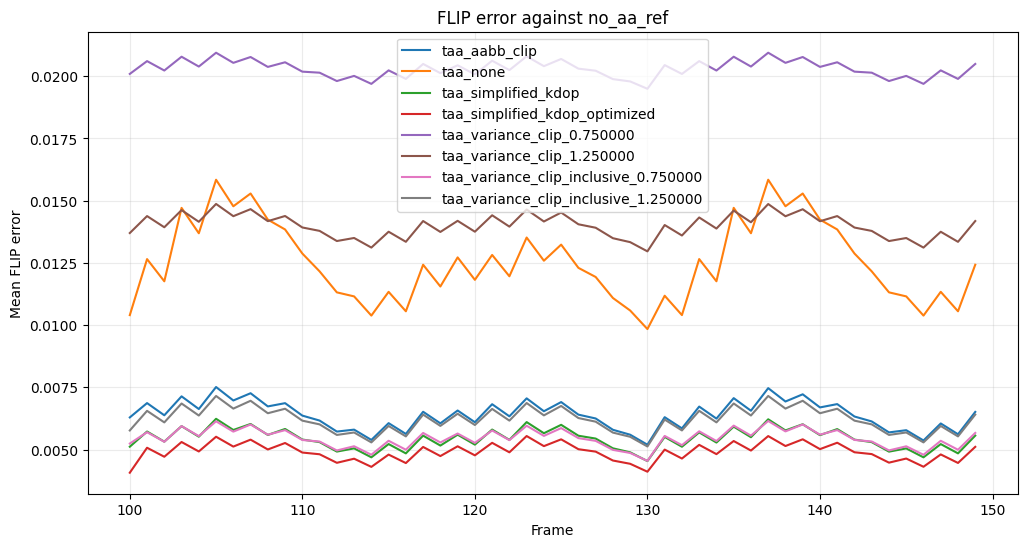

In [153]:
fig, ax = plt.subplots(figsize=(12, 6))

for method, frames in results.groupby("method"):
    ax.plot(frames["frame"], frames["mean_flip"], label=method)

ax.set(
    xlabel="Frame",
    ylabel="Mean FLIP error",
    title=f"FLIP error against {reference_dir.name}",
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [162]:
output_dir = root / "Flip" / "results"
output_dir.mkdir(parents=True, exist_ok=True)

results.to_csv(output_dir / "frame_results.csv", index=False)
summary.to_csv(output_dir / "method_summary.csv")

target_frame = 130

for method, frames in results.groupby("method"):
    matches = frames.loc[frames["frame"] == target_frame]

    if matches.empty:
        print(f"{method}: frame {target_frame} not found")
        continue

    row = matches.iloc[0]

    error_map, mean_flip, _ = flip.evaluate(
        row["reference"],
        row["test"],
        "LDR",
        applyMagma=True,
    )

    destination = output_dir / f"{method}_frame_{target_frame}.png"
    plt.imsave(destination, error_map)

    print(method, target_frame, mean_flip, destination)

taa_aabb_clip 130 0.005194441415369511 c:\Users\whydi\source\repos\whydidyoumakethis\masters-dissertation\Flip\results\taa_aabb_clip_frame_130.png
taa_none 130 0.009841112419962883 c:\Users\whydi\source\repos\whydidyoumakethis\masters-dissertation\Flip\results\taa_none_frame_130.png
taa_simplified_kdop 130 0.004536660388112068 c:\Users\whydi\source\repos\whydidyoumakethis\masters-dissertation\Flip\results\taa_simplified_kdop_frame_130.png
taa_simplified_kdop_optimized 130 0.004109998699277639 c:\Users\whydi\source\repos\whydidyoumakethis\masters-dissertation\Flip\results\taa_simplified_kdop_optimized_frame_130.png
taa_variance_clip_0.750000 130 0.019494786858558655 c:\Users\whydi\source\repos\whydidyoumakethis\masters-dissertation\Flip\results\taa_variance_clip_0.750000_frame_130.png
taa_variance_clip_1.250000 130 0.012963203713297844 c:\Users\whydi\source\repos\whydidyoumakethis\masters-dissertation\Flip\results\taa_variance_clip_1.250000_frame_130.png
taa_variance_clip_inclusive_0.75